# Laboratorio 2: Caracterización de ruido en canal inalámbrico

El objetivo de esta práctica es caracterizar el ruido presente en el canal de comunicaciones inalámbrico. Para ello se recibe la señal del SDR cuando el transmisor no está enviando ninguna señal útil, y se analizan las componentes en fase (I) y en cuadratura (Q) obtenidas.

## Instalación de dependencias

In [1]:
#!pip install pyadi-iio matplotlib scipy statsmodels

## Importación de librerías

In [2]:
import adi
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter


## Parámetros de configuración del SDR

Se configuran los parámetros según la consigna para poder "escuchar" el canal con la mínima interferencia posible:
- **TxAtten = -70 dB**: atenuación máxima del transmisor para minimizar interferencia propia.
- **GainControlModes = "manual"** y **RxHardwareGain = 70 dB**: ganancia máxima en recepción para captar el ruido del canal.
- **Tx_cyclic_buffer = False**: no se transmite ninguna señal en bucle.
- **RxBufferSize = 2²⁰**: tamaño del buffer para obtener suficientes muestras.

In [3]:
Uri              = "ip:192.168.1.32"
Loopback         = 0
Tx_cyclic_buffer = False
TxAtten          = -70
GainControlModes = "manual"
RxHardwareGain   = 70
RxBufferSize     = 2**20

# Parámetros adicionales elegidos por el usuario
SamplingRate     = 2.0e6             # Frecuencia de muestreo [Samples/seg]
RxLOFreq         = 915e6             # Frecuencia portadora RX [Hz]
TxLOFreq         = 2400e6            # Frecuencia portadora TX [Hz] (diferente a RX para minimizar interferencia)
RfBw             = 2.0e6             # Ancho de banda del filtro analógico [Hz]

## Conexión al SDR

Se crea el objeto `sdr` vinculándolo con el dispositivo en la dirección `Uri`. Si el SDR `.32` no está disponible, modificar la variable `Uri` para apuntar a otro dispositivo (`.31` a `.35`).

In [4]:
sdr = adi.Pluto(Uri)
print(f"Conectado a: {Uri}")

Conectado a: ip:192.168.1.32


## Configuración de parámetros en el hardware

Se aplican los parámetros al SDR siguiendo el mismo orden que en el Laboratorio 1.

In [5]:
#------------------------------- Configuración del SDR -------------------------------
sdr.loopback                = Loopback
sdr.sample_rate             = int(SamplingRate)
sdr.tx_rf_bandwidth         = int(RfBw)
sdr.rx_rf_bandwidth         = int(RfBw)
sdr.tx_lo                   = int(TxLOFreq)
sdr.rx_lo                   = int(RxLOFreq)
sdr.tx_hardwaregain_chan0    = TxAtten
sdr.gain_control_mode_chan0  = GainControlModes
sdr.rx_hardwaregain_chan0    = RxHardwareGain
sdr.rx_buffer_size           = RxBufferSize
sdr.tx_cyclic_buffer         = Tx_cyclic_buffer

print("Configuración aplicada:")
print(f"  Loopback          : {sdr.loopback}")
print(f"  Sample rate       : {sdr.sample_rate / 1e6:.1f} MSPS")
print(f"  TX LO             : {sdr.tx_lo / 1e6:.1f} MHz")
print(f"  RX LO             : {sdr.rx_lo / 1e6:.1f} MHz")
print(f"  TX atenuación     : {sdr.tx_hardwaregain_chan0} dB")
print(f"  RX ganancia       : {sdr.rx_hardwaregain_chan0} dB")
print(f"  Control ganancia  : {sdr.gain_control_mode_chan0}")
print(f"  RX buffer size    : {sdr.rx_buffer_size} muestras")

Configuración aplicada:
  Loopback          : 0
  Sample rate       : 2.0 MSPS
  TX LO             : 2400.0 MHz
  RX LO             : 915.0 MHz
  TX atenuación     : -70 dB
  RX ganancia       : 70 dB
  Control ganancia  : manual
  RX buffer size    : 1048576 muestras


## Captura de muestras de ruido

Con el transmisor en silencio (atenuación máxima, `Tx_cyclic_buffer = False`), se llama directamente a `sdr.rx()` para capturar las muestras del canal. Lo que se recibe es el **ruido térmico** del receptor más cualquier interferencia del entorno.

In [6]:
rxNoise = sdr.rx()

print(f"Muestras capturadas : {len(rxNoise)}")
print(f"Tipo de dato        : {rxNoise.dtype}")
print(f"Componente I (real) — min: {np.real(rxNoise).min():.1f}, max: {np.real(rxNoise).max():.1f}")
print(f"Componente Q (imag) — min: {np.imag(rxNoise).min():.1f}, max: {np.imag(rxNoise).max():.1f}")

Muestras capturadas : 1048576
Tipo de dato        : complex128
Componente I (real) — min: -47.0, max: 46.0
Componente Q (imag) — min: -55.0, max: 53.0


## Gráfica temporal de las componentes I y Q

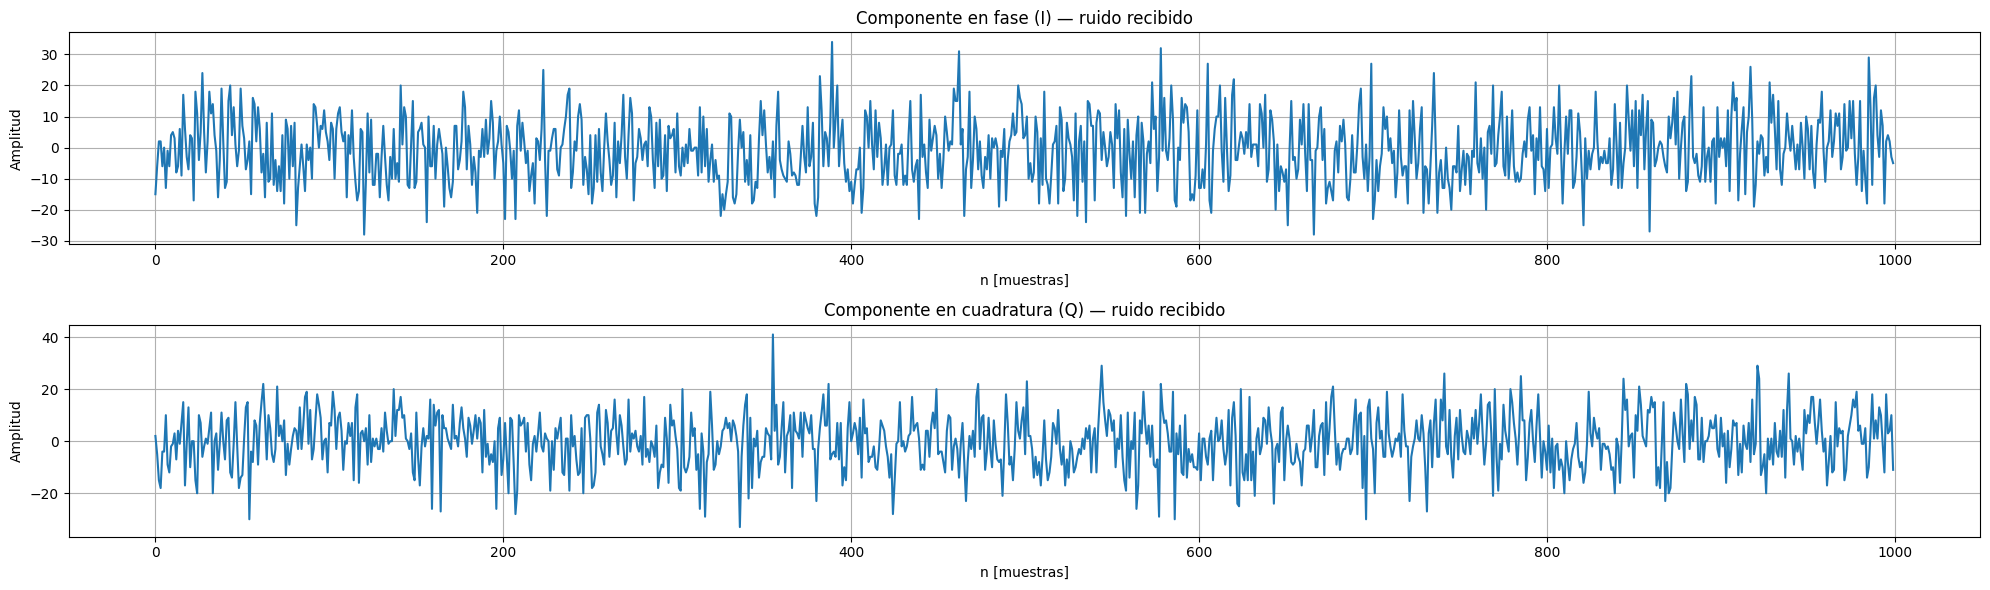

In [7]:
N_plot = 1000  # Cantidad de muestras a graficar (el total es muy grande para visualizar)

plt.figure(figsize=(20, 6))

plt.subplot(2, 1, 1)
plt.plot(np.real(rxNoise[:N_plot]))
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Componente en fase (I) — ruido recibido")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(np.imag(rxNoise[:N_plot]))
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Componente en cuadratura (Q) — ruido recibido")
plt.grid()

plt.tight_layout()
plt.show()

## Gráfica en frecuencia — Densidad Espectral de Potencia (PSD)

/tmp/ipykernel_226519/858321507.py:4: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(rxNoise, len(rxNoise), SamplingRate, color="C1")


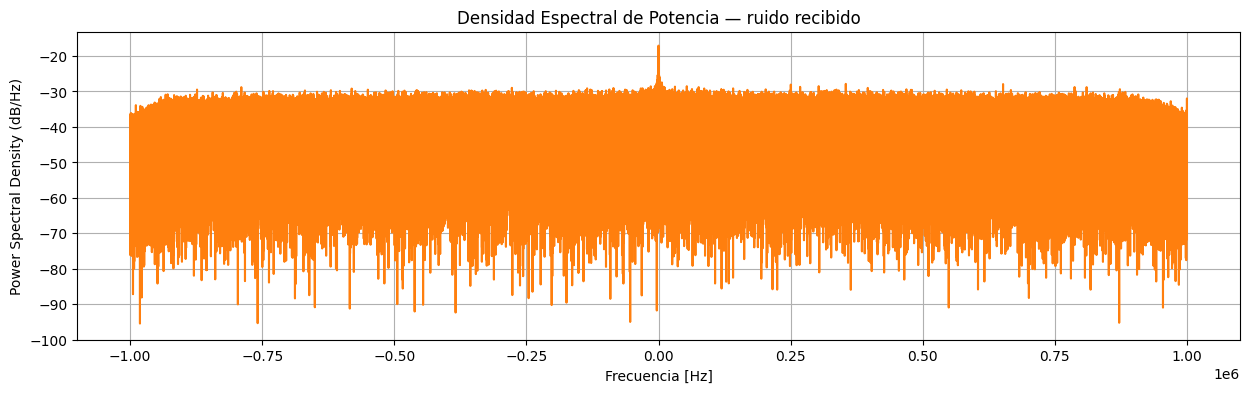

In [8]:
plt.figure(figsize=(15, 4))
plt.grid()
plt.title("Densidad Espectral de Potencia — ruido recibido")
plt.psd(rxNoise, len(rxNoise), SamplingRate, color="C1")
plt.xlabel("Frecuencia [Hz]")
plt.show()

## Media y varianza

Las muestras se almacenan en `rxNoise`, un array de `N` números complejos.
Los componentes en fase y cuadratura son su parte real e imaginaria respectivamente.

Las fórmulas aplicadas son:
$$\bar{x} = \frac{1}{N} \sum_{k=0}^{N-1} x_k$$
$$\sigma^2 = \frac{1}{N} \sum_{k=0}^{N-1} (x_k - \bar{x})^2$$



In [9]:
I = np.real(rxNoise)
Q = np.imag(rxNoise)
N = len(rxNoise)

print(N)

# Cálculo de la media
media_I = np.sum(I)/N
media_Q = np.sum(Q)/N

# Cálculo de varianza
var_I = np.sum((I - media_I)**2) / N 
var_Q = np.sum((Q - media_Q)**2) / N

print(f"Componente I — media: {media_I:.4f}  |  varianza: {var_I:.4f}")
print(f"Componente Q — media: {media_Q:.4f}  |  varianza: {var_Q:.4f}")  

1048576
Componente I — media: 0.0115  |  varianza: 108.1667
Componente Q — media: -0.0139  |  varianza: 107.8826


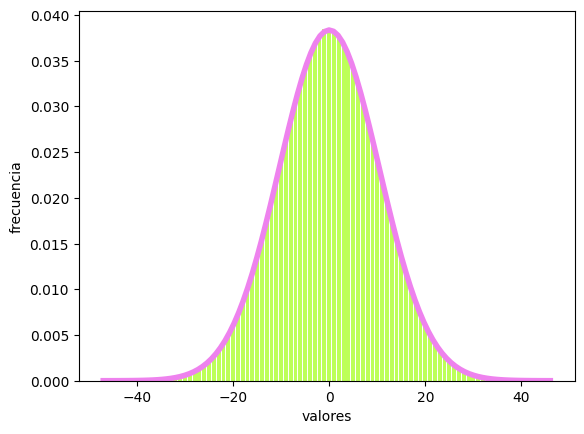

In [10]:
hist = Counter(I)

x_I = np.linspace(min(I), max(I), 100)

for k in hist:
    hist[k] /= N 

y_I = (1/(np.sqrt(var_I) * np.sqrt(2*np.pi))) * np.exp(-((x_I - media_I)**2) / (2*var_I))


plt.bar(list(hist.keys()),list(hist.values()), color = "#ADFF2F", alpha = 0.8)
plt.plot(x_I,y_I, linewidth = 4, color = "violet")

plt.xlabel("valores")
plt.ylabel("frecuencia")
plt.show()

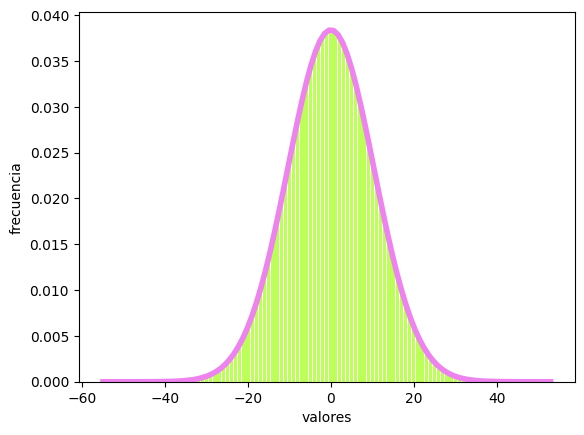

In [11]:
hist = Counter(Q)

x_Q = np.linspace(min(Q), max(Q), 100)

for k in hist:
    hist[k] /= N 

y_Q = (1/(np.sqrt(var_Q) * np.sqrt(2*np.pi))) * np.exp(-((x_Q - media_Q)**2) / (2*var_Q))

plt.bar(list(hist.keys()),list(hist.values()), color = "#ADFF2F", alpha = 0.8)
plt.plot(x_Q,y_Q, linewidth = 4, color = "violet")

plt.xlabel("valores")
plt.ylabel("frecuencia")
plt.show()

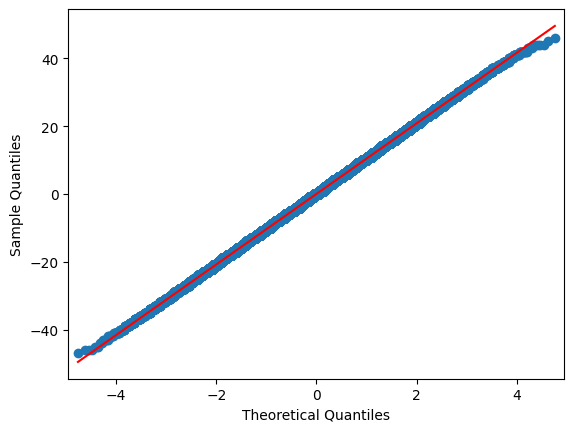

In [12]:
sm.qqplot(I, line = 's')
plt.show()

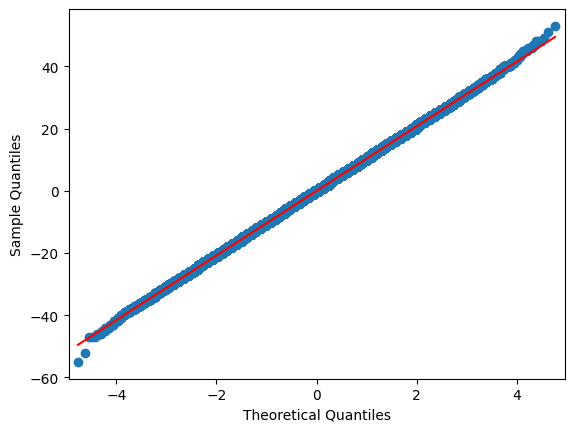

In [13]:
sm.qqplot(Q, line = 's')
plt.show()

[ 54. -15.  70. ... 173. -97.  12.]


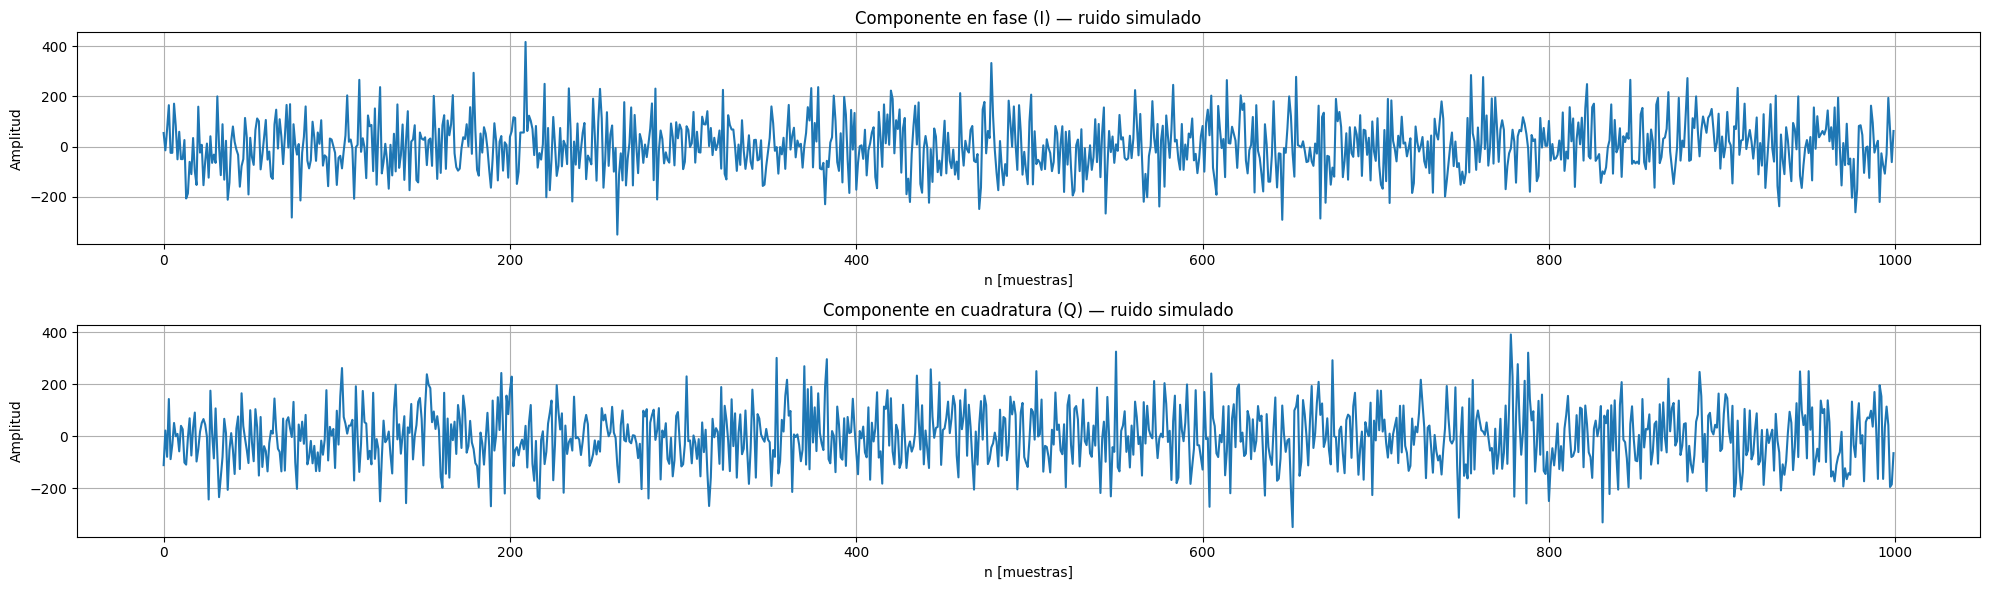

In [14]:
np.random.seed(42)
I_sim = np.round(np.random.normal(media_I, var_I, 1048576))
Q_sim = np.round(np.random.normal(media_Q, var_Q, 1048576))
rx_Sim = I_sim + 1j * Q_sim
rx_Sim = np.round(rx_Sim)

N_plot = 1000  # Cantidad de muestras a graficar (el total es muy grande para visualizar)

print(I_sim)

plt.figure(figsize=(20, 6))

plt.subplot(2, 1, 1)
plt.plot(np.real(rx_Sim[:N_plot]))
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Componente en fase (I) — ruido simulado")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(np.imag(rx_Sim[:N_plot]))
plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Componente en cuadratura (Q) — ruido simulado")
plt.grid()

plt.tight_layout()
plt.show()


/tmp/ipykernel_226519/982227793.py:4: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(rx_Sim, len(rx_Sim), SamplingRate, color="C1")


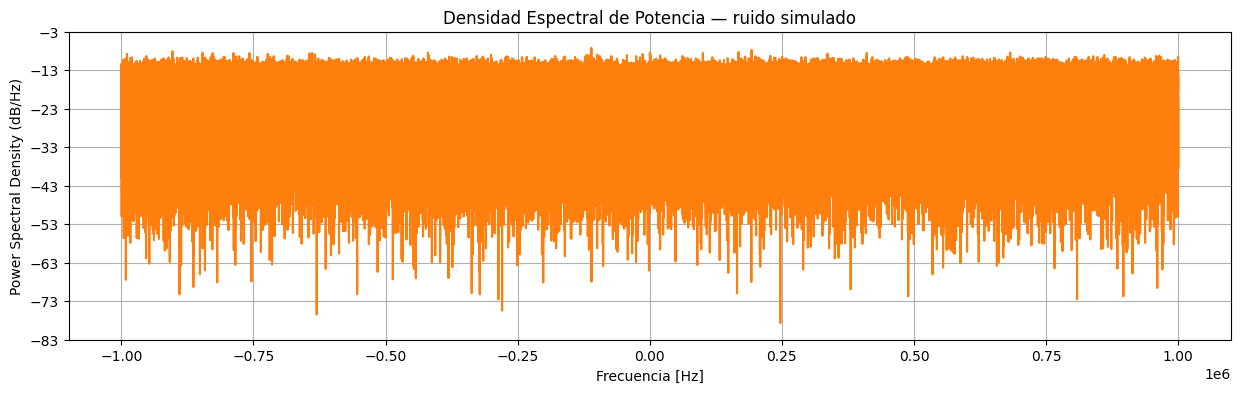

In [15]:
plt.figure(figsize=(15, 4))
plt.grid()
plt.title("Densidad Espectral de Potencia — ruido simulado")
plt.psd(rx_Sim, len(rx_Sim), SamplingRate, color="C1")
plt.xlabel("Frecuencia [Hz]")
plt.show()

## Histogramas de los simulados

In [16]:
hist_sim = Counter(I_sim)

In [17]:
x_I_sim = np.round(np.linspace(min(I_sim), max(I_sim), 100))

In [18]:
N_sim = len(rx_Sim)

for k in hist_sim:
    hist_sim[k] /= N_sim 

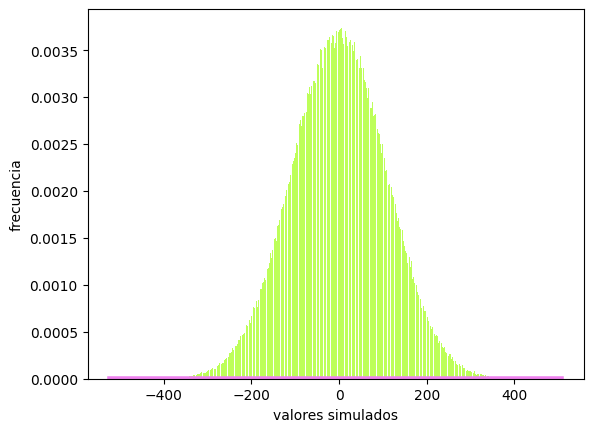

In [19]:
# Parte Real simulada

y_I_sim = np.round((1/(np.sqrt(var_I) * np.sqrt(2*np.pi))) * np.exp(-((x_I_sim - media_I)**2) / (2*var_I)))


plt.bar(list(hist_sim.keys()),list(hist_sim.values()), color = "#ADFF2F", alpha = 0.8)
plt.plot(x_I_sim,y_I_sim, linewidth = 4, color = "violet")

plt.xlabel("valores simulados")
plt.ylabel("frecuencia")
plt.show()

In [20]:
#plt.bar(list(hist_sim.keys()),list(hist_sim.values()), color = "#ADFF2F", alpha = 0.8)hist = Counter(I)

In [21]:
# Parte Imaginaria Simulada

#hist_sim = Counter(Q_sim)
#
#x_Q_sim = np.linspace(min(Q_sim), max(Q_sim), 100)
#
#for k in hist_sim:
#    hist_sim[k] /= N 
#
#y_Q_sim = (1/(np.sqrt(var_Q) * np.sqrt(2*np.pi))) * np.exp(-((x_Q_sim - media_Q)**2) / (2*var_Q))
#
#plt.bar(list(hist_sim.keys()),list(hist_sim.values()), color = "#ADFF2F", alpha = 0.8)
#plt.plot(x_Q_sim,y_Q_sim, linewidth = 4, color = "violet")
#
#plt.xlabel("valores")
#plt.ylabel("frecuencia")
#plt.show()

In [22]:
# Since it is not possible to turn off Tx, it is configured to transmit at low power and on a different frequency than Rx.
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89 
sdr.tx_lo                 = int(2400e6)
sdr.rx_lo                 = int(950e6)
sdr.tx(np.zeros(2048))

In [23]:
del(sdr)